In [19]:
from dace_query.sun import Sun

from astropy.io import fits
from astropy.time import Time
from astropy.timeseries import LombScargle

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

from scipy.optimize import curve_fit
from sklearn.decomposition import PCA

import re  # find pattern in string
from tqdm import tqdm  # progress bar
import logging  # to avoid printing too many warnings

import tools as t

In [20]:
# get RV data of the Sun
# from Dace tutorial: https://dace.unige.ch/pythonAPI/?tutorialId=800

data_original = Sun.query_database(output_format="pandas", limit=200000)
to_keep = data_original.spectro_drs_qc == 1
data_ccf = data_original[to_keep]

In [21]:
# extract time and radial velocity from the data
time   = data_ccf.obj_date_bjd  # Barycentric Julian Date
rv_sun = data_ccf.spectro_ccf_rv  # m/s

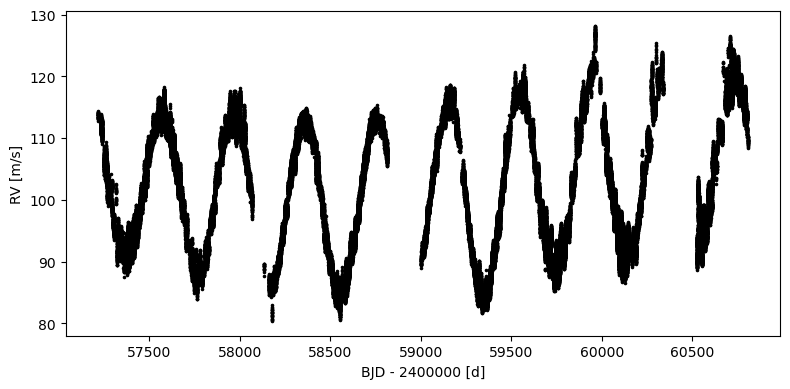

In [22]:
# plot the raw radial velocities, in the Solar System barycenter rest frame
plt.figure(figsize=(8, 4))
plt.scatter(time, rv_sun, marker='.', s=10, color='k')
plt.xlabel('BJD - 2400000 [d]')
plt.ylabel('RV [m/s]')
plt.tight_layout()

In [23]:
# perform fit
# initial guess for P is the synodic period of Jupiter
fit = curve_fit(t.RV_jup, time, rv_sun, p0=[1, 1, 398, 1, 1])
A_0 , A_1, P, phi, C = fit[0]

In [24]:
# create time array to plot the fit as a function of it
time_fit = np.linspace(min(time), max(time), 500)

# calculate the sinusoidal function for the time array
rv_sun_fit = np.array([])
for i in time_fit:
    y = t.RV_jup(i, A_0, A_1, P, phi, C)
    rv_sun_fit = np.append(rv_sun_fit, y)

# calculate residuals
res = rv_sun - t.RV_jup(time, A_0 , A_1, P, phi, C)

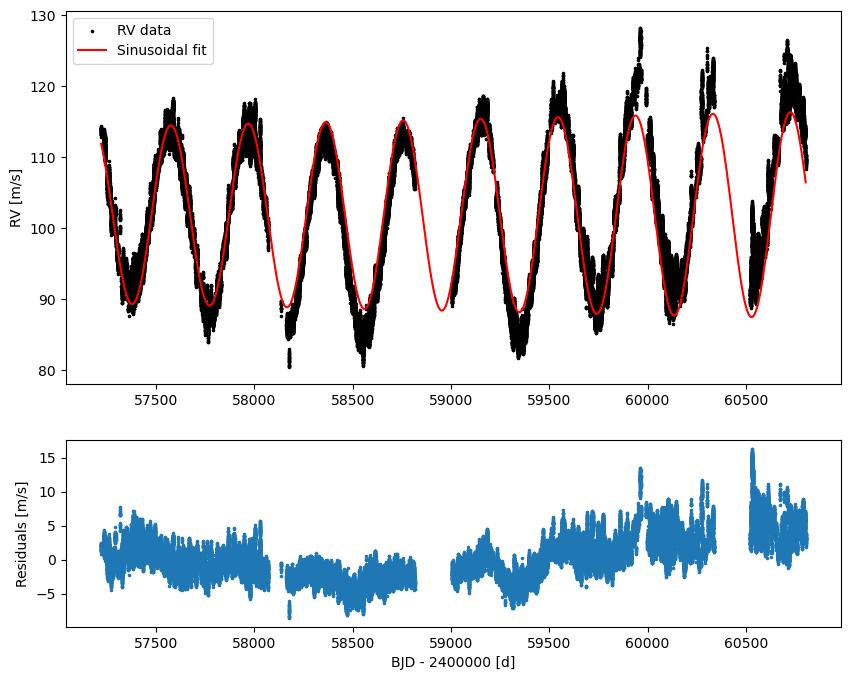

In [25]:
# plot data and fit
fig, axs = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[2, 1])
axs[0].scatter(time, rv_sun, marker='.', s=10, color='k', label='RV data')
axs[0].plot(time_fit, rv_sun_fit, color='red', label='Sinusoidal fit')
axs[0].set_ylabel('RV [m/s]')
axs[0].legend()
axs[1].scatter(time, res, marker='.', s=10)
axs[1].set_xlabel('BJD - 2400000 [d]')
axs[1].set_ylabel('Residuals [m/s]')
plt.show()

## Spectra

In [26]:
# get data corresponding to 2017 and 2018

path_dace = '../data/dace_sun/'  # define the path of the directory where the data is saved

# maximum one file per day
data_spec = data_ccf[data_ccf['date_night'] < '2019']  # end date
data_spec = data_spec['2017' < data_spec['date_night']]  # start date
data_spec = data_spec.sort_values('obj_date_bjd')  # sort
dates_ccf = data_spec['date_night'].to_numpy()  # observation dates (just date, not time)
files_ccf = data_spec['file_rootpath'].to_numpy()  # file names
dates_ccf

array(['2017-01-02', '2017-01-02', '2017-01-02', ..., '2018-12-31',
       '2018-12-31', '2018-12-31'], shape=(23133,), dtype=object)

In [27]:
# load absorption bands
bands = np.genfromtxt('../data/bands.txt', dtype=None, encoding=None, names=True, delimiter=',')

In [28]:
# extract data from saved files
# example for one file
filename = path_dace + '2017-2018/2017-01-06/r.HARPN.2017-01-06T10-14-37.087_S1D_A.fits'
s1d = fits.getdata(filename, 1)  # load file
wl = s1d['wavelength_air']  # angstrom
s1d.columns

ColDefs(
    name = 'wavelength'; format = '1D'; unit = 'angstrom'
    name = 'wavelength_air'; format = '1D'; unit = 'angstrom'
    name = 'flux'; format = '1D'; unit = 'e-'
    name = 'error'; format = '1D'; unit = 'e-'
    name = 'quality'; format = '1J'
)

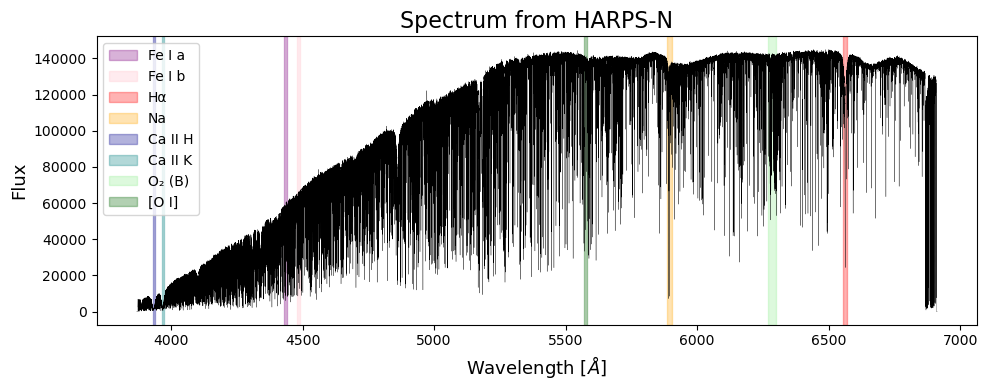

In [29]:
# plot spectrum
plt.figure(figsize=(10, 4))
plt.plot(wl, s1d['flux'], linewidth=.2, color='k')
for j in bands:
        plt.axvspan(xmin=j['start']*10, xmax=j['end']*10, color=j['color'], label=j['name'], alpha=.3)
plt.title('Spectrum from HARPS-N', size=16)
plt.xlabel(r'Wavelength [$\AA$]', size=13)
plt.ylabel('Flux', size=13)
plt.legend()
plt.tight_layout()

In [30]:
# iterate over saved files from 2017 to 2018
# save names (observation dates) of the files
dates_files = []
for entry in os.scandir(path_dace + '2017-2018'):
    if entry.name != 'spectra.txt':
        dates_files.append(entry.name)

dates_files = sorted(dates_files, key=lambda d: datetime.strptime(d, "%Y-%m-%d"))  # sort
print(dates_files)

['2017-01-06', '2017-01-09', '2017-01-15', '2017-01-16', '2017-01-18', '2017-01-19', '2017-01-21', '2017-01-23', '2017-01-24', '2017-01-25', '2017-02-05', '2017-02-06', '2017-02-08', '2017-02-13', '2017-02-20', '2017-02-23', '2017-02-25', '2017-02-26', '2017-02-27', '2017-02-28', '2017-03-01', '2017-03-02', '2017-03-03', '2017-03-04', '2017-03-05', '2017-03-07', '2017-03-08', '2017-03-09', '2017-03-12', '2017-03-13', '2017-03-16', '2017-03-23', '2017-03-24', '2017-03-27', '2017-03-28', '2017-04-01', '2017-04-02', '2017-04-05', '2017-04-06', '2017-04-09', '2017-04-12', '2017-04-13', '2017-04-14', '2017-04-16', '2017-04-17', '2017-04-18', '2017-04-21', '2017-04-23', '2017-04-24', '2017-04-30', '2017-05-02', '2017-05-03', '2017-05-05', '2017-05-07', '2017-05-13', '2017-05-18', '2017-05-19', '2017-05-21', '2017-05-22', '2017-05-23', '2017-05-24', '2017-05-25', '2017-05-26', '2017-05-27', '2017-05-28', '2017-05-29', '2017-05-30', '2017-05-31', '2017-06-01', '2017-06-02', '2017-06-03', '2017

In [31]:
# make a list of the available files that end by A.fits
files_list = []
for d in dates_files:  # iterate over directories
    date_path = f'{path_dace}2017-2018/{d}/'
    files = os.scandir(date_path)  # files in directory
    files = list(files)
    files = [d + '/' + i.name for i in files]  # list of file names
    files_list.extend(files)  # save file names
files_list = [s for s in files_list if s.endswith('A.fits')]  # keep only the files that end by A.fits
files_list = np.array(files_list)
len(files_list)

596

In [32]:
# save spectra in matrix rows
# the row i from spectra contains the spectrum from the file i from files_list
spectra = []
err = []
for f in files_list:  # iterate over files
    file_path = path_dace + '2017-2018/' + f
    hdul = fits.open(file_path)  # open file
    spectra.append(hdul[1].data['flux'])  # save spectrum
    err.append(hdul[1].data['error'])  # save flux error
            
spectra = np.array(spectra)
err = np.array(err)
print(spectra.shape, err.shape)

(596, 212207) (596, 212207)


In [33]:
# get corresponding RV data
# extract datetime from file names (file_rootpath) in data_spec
pattern = re.compile(r"\d{4}-\d{2}-\d{2}T\d{2}-\d{2}-\d{2}\.\d+")  # pattern to look for in the files names

times_files = {}  # datetime string: ccf file name
for sequence in files_ccf:  # iterate over files names
    time_str = t.extract_pattern(sequence, pattern)  # get the observation time from the file's name
    if time_str:
        times_files[time_str] = sequence

measure_times = sorted(list(times_files.keys()))  # sorted observation times
print(len(measure_times))

# find files in file_list (downloaded spectra) that have a corresponding ccf file
matches = []  # contains tuples of the form: (name_of_spectrum_file, name_of_ccf_file)
times = []  # list of datetime objects corresponding to the files that are actually used

for sequence in files_list:  # iterate over files names
    time_str = t.extract_pattern(sequence, pattern)  # get the observation time from the file's name
    if time_str in times_files:
        matches.append((sequence, times_files[time_str]))
        times.append(datetime.strptime(time_str, '%Y-%m-%dT%H-%M-%S.%f'))

matches = np.array(matches)
times = np.array(sorted(times))
times_jd = np.array([Time(i).jd for i in times])  # convert to Julian Date to simplify some plots

23133


In [34]:
# RV data from data_spec recovered from the rows where the column 'file_rootpath' is in the list of matches
RV_list = data_spec[data_spec['file_rootpath'].isin(matches[:, 1])]['spectro_ccf_rv'].to_numpy()
len(RV_list)

596

In [35]:
# calculate lambda_corr for each observation
lambda_corr = t.calculate_lambda_corr(wl, RV_list)  # corrected wavelength in Angstrom

In [36]:
# interpolation to a common reference grid
# choose a reference wavelength grid
wmin = max(w.min() for w in lambda_corr)  # max to ensure all spectra cover the chosen range
wmax = min(w.max() for w in lambda_corr)  # min to ensure all spectra cover the chosen range
print(f'New wavelength range: {round(wmin, 1)} to {round(wmax, 1)} angstrom.')
wl_ref = np.linspace(wmin, wmax, len(wl))

# interpolate
resampled_flux = []

for wave, flux in zip(lambda_corr, spectra):  # iterate over wavelength, spectrum pairs
    interp_flux = np.interp(wl_ref, wave, flux)  # interpolate the observed spectrum into the reference grid
    resampled_flux.append(interp_flux)  # save

spectra_matrix = np.array(resampled_flux)

New wavelength range: 3868.9 to 6913.0 angstrom.


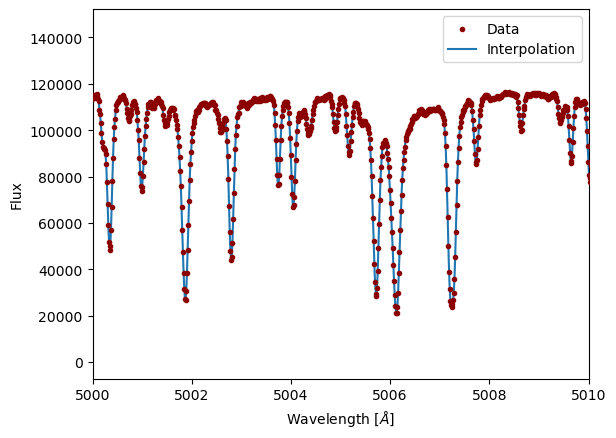

In [37]:
# check interpolation
wl_test = lambda_corr[0]  # define a test wavelength list
flux_test = spectra[0]  # define a test spectrum
interp_test = np.interp(wl_ref, wl_test, flux_test)  # interpolate

plt.scatter(wl_test, flux_test, color='darkred', marker='.', label='Data', zorder=4)
plt.plot(wl_ref, interp_test, label='Interpolation')
plt.xlim(5000, 5010)
plt.xlabel(r'Wavelength [$\AA$]')
plt.ylabel('Flux')
plt.legend()
plt.show()

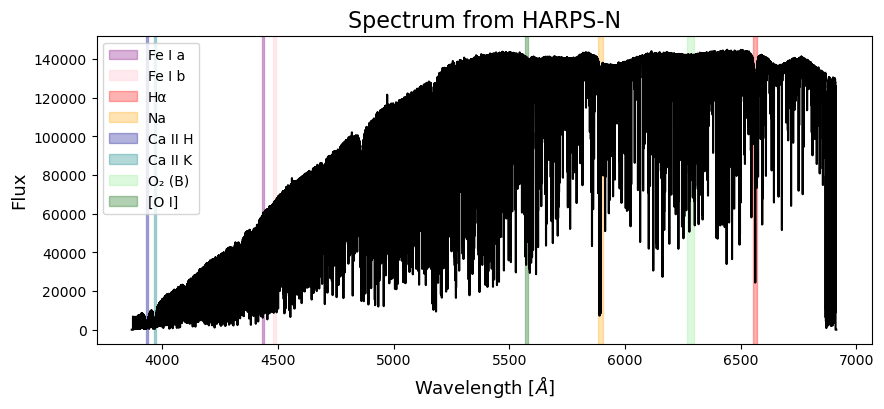

In [39]:
# check interpolation
wl_test = lambda_corr[0]  # define a test wavelength list
flux_test = spectra[0]  # define a test spectrum
interp_test = np.interp(wl_ref, wl_test, flux_test)  # interpolate

plt.figure(figsize=(10, 4))
plt.plot(wl_ref, interp_test, color='k')
for j in bands:
        plt.axvspan(xmin=j['start']*10, xmax=j['end']*10, color=j['color'], label=j['name'], alpha=.3)
plt.title('Spectrum from HARPS-N', size=16)
plt.xlabel(r'Wavelength [$\AA$]', size=13)
plt.ylabel('Flux', size=13)
plt.legend()
plt.show()

In [34]:
arr1 = np.array([12, 15, 17, 22, 3])
arr1 = np.delete(arr1, 1)
arr1

array([12, 17, 22,  3])

In [67]:
wl_test[93900]

np.float64(5001.863036436586)

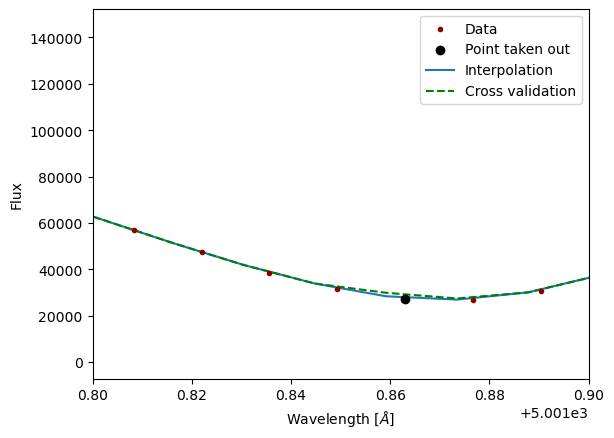

In [80]:
# cross validation

wl_cross = np.delete(lambda_corr[0], 93900)  # define a cross validation wavelength list
flux_cross = np.delete(spectra[0], 93900)  # define a cross validation spectrum
interp_cross = np.interp(wl_ref, wl_cross, flux_cross)  # interpolate

plt.scatter(wl_test, flux_test, color='darkred', marker='.', label='Data', zorder=4)
plt.scatter(wl_test[93900], flux_test[93900], zorder=5, color='k', label='Point taken out')
plt.plot(wl_ref, interp_test, label='Interpolation')
plt.plot(wl_ref, interp_cross, label='Cross validation', color='g', linestyle='--')
plt.xlim(5001.8, 5001.9)
plt.xlabel(r'Wavelength [$\AA$]')
plt.ylabel('Flux')
plt.legend()
plt.show()

In [24]:
# apply double centering to the spectra matrix
spectra_centered = t.double_centering(spectra_matrix)

In [25]:
# apply PCA to the centered spectra matrix
n_components = 40
pca_flux = PCA(n_components=n_components)  # create PCA object
pcs  = pca_flux.fit_transform(spectra_centered)  # fit the model with spectra_centered and apply the dimensionality reduction
var  = pca_flux.explained_variance_ratio_
print(f'Variance explained by the {n_components} components:', var)  # how much information (variance) can be attributed to each of the principal components

Variance explained by the 40 components: [9.34185596e-01 4.88476768e-02 7.38431697e-03 3.97571544e-03
 1.92824015e-03 2.96239722e-04 1.46143814e-04 1.19367854e-04
 9.07998200e-05 8.14916775e-05 6.98377291e-05 5.16170142e-05
 3.80220186e-05 3.41934206e-05 2.65582926e-05 2.50089278e-05
 1.95708329e-05 1.64954558e-05 1.54147849e-05 1.35831147e-05
 1.30557592e-05 1.21735041e-05 1.14210249e-05 1.09658828e-05
 1.02679716e-05 1.02180645e-05 9.94578869e-06 9.69730886e-06
 9.30086307e-06 9.10385059e-06 8.85120939e-06 8.74188648e-06
 8.62964771e-06 8.45920915e-06 8.34726671e-06 8.28543725e-06
 8.21838108e-06 8.00585923e-06 7.96316327e-06 7.85025407e-06]


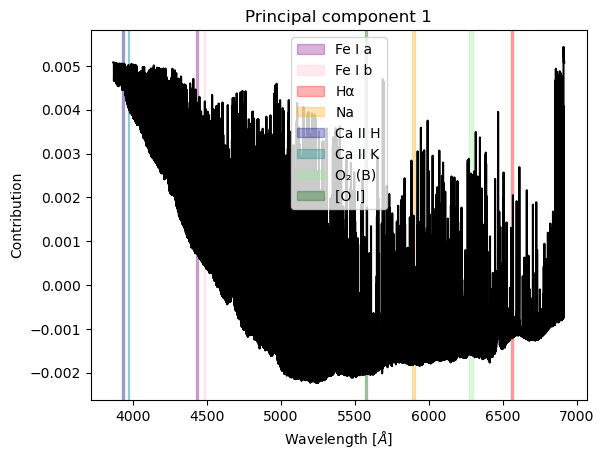

In [26]:
# plot loadings
# plot shows how much each wavelength value (feature) contributes to the variance of a PC
for i in range(1):  # put n_components instead of 1 to see all the plots
    plt.plot(wl, pca_flux.components_[i], color='k')
    for j in bands:
        plt.axvspan(xmin=j['start']*10, xmax=j['end']*10, color=j['color'], label=j['name'], alpha=.3)
    plt.title(f'Principal component {i + 1}', size=12)
    plt.xlabel(r'Wavelength [$\AA$]')
    plt.ylabel('Contribution')
    plt.legend()
    plt.show()

In [27]:
# component significance
# multiple realizations allow to calculate error bars

n_realizations = 20

# reduce the size of the data to reduce memory usage
spectra_centered = spectra_centered.astype(np.float32)
err = err.astype(np.float32)
comps = pca_flux.components_.astype(np.float32)

simi_all = np.empty((n_realizations, n_components, n_components), dtype=np.float32)  # n_realizations squared matrices of n_components x n_components

for i in tqdm(range(n_realizations)):  # iterate over realizations
    spectra_noisy = spectra_centered + np.random.normal(0, err)  # add gaussian noise to the original data

    pca_noisy = PCA(n_components=n_components, svd_solver="randomized")  # apply PCA to the noisy matrix
    pca_noisy.fit(spectra_noisy)

    comps_noisy = pca_noisy.components_  # save the loadings

    simi_all[i] = comps @ comps_noisy.T  # save dot product between original and noisy loadings

100%|██████████| 20/20 [05:35<00:00, 16.77s/it]


In [28]:
maxes = np.array([np.amax(s, axis=1) for s in simi_all])  # max of each row of each realization
mean_maxes = np.array([(np.average(s), np.std(s)) for s in maxes.T])  # list of max mean and std for each PC: [(max_avg_1, max_std_1), (max_avg_2, max_std_2), ..., (max_avg_n, max_std_n)]

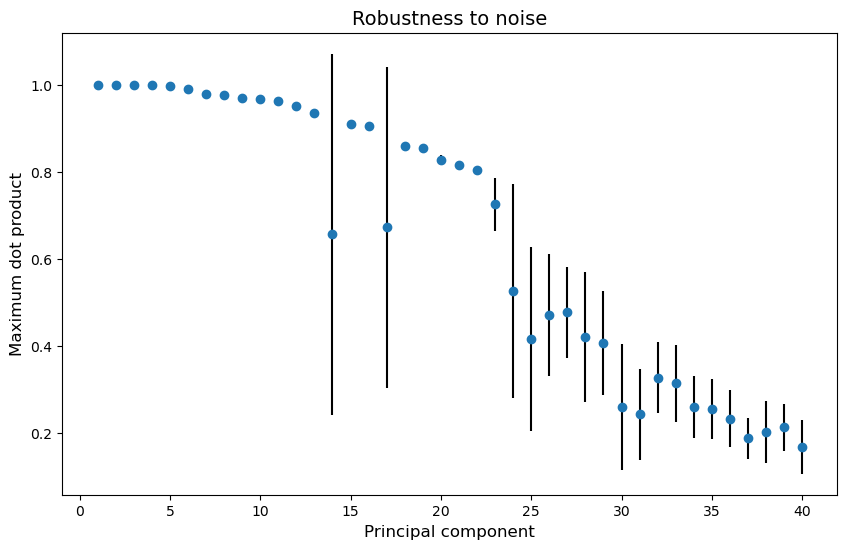

In [29]:
# plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(np.linspace(1, n_components, n_components), mean_maxes[:, 0], mean_maxes[:, 1], fmt='o', ecolor='k')
ax.set_title('Robustness to noise', size=14)
ax.set_xlabel('Principal component', size=12)
ax.set_ylabel('Maximum dot product', size=12)
plt.show()

In [ ]:
# Periodograms (Lomb-Scargle because the timestep between observations is irregular)
# https://docs.astropy.org/en/latest/timeseries/lombscargle.html

periodograms = [LombScargle(times_jd, pcs[:, i]).autopower() for i in range(n_components)]

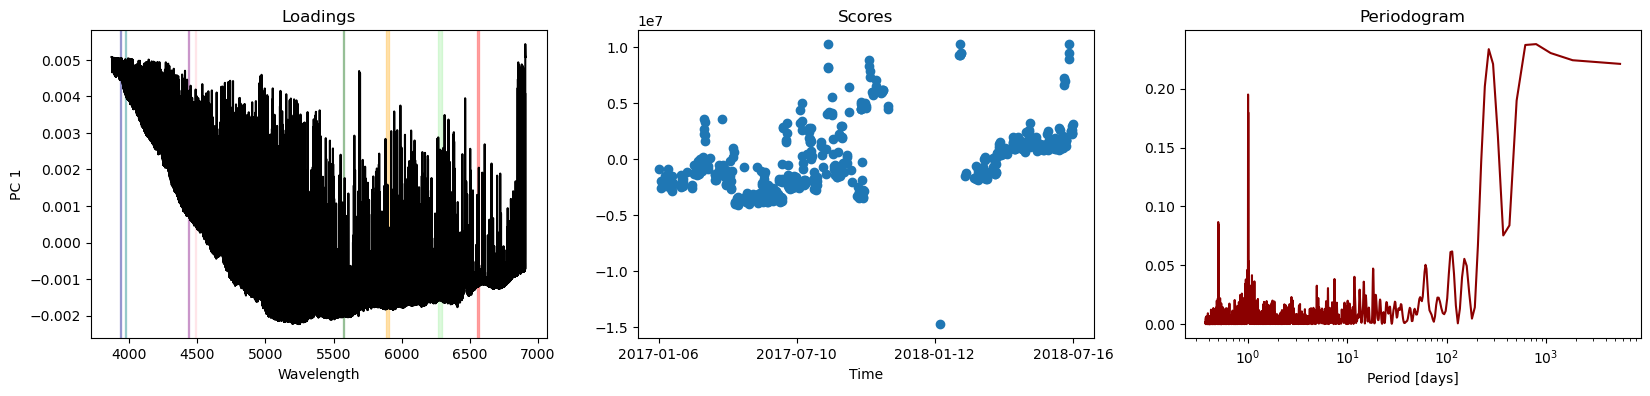

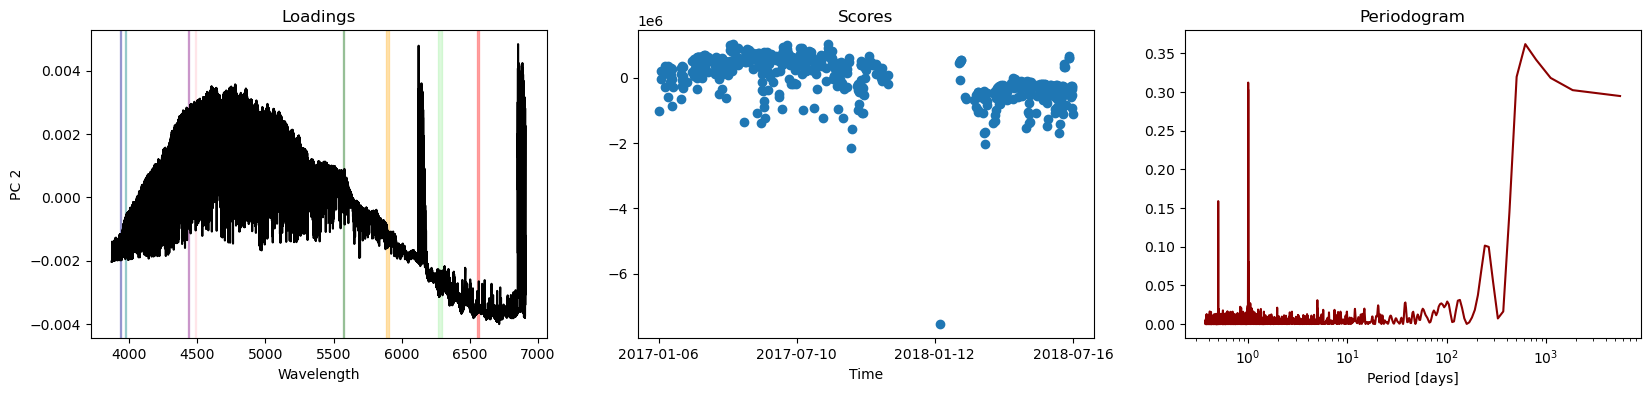

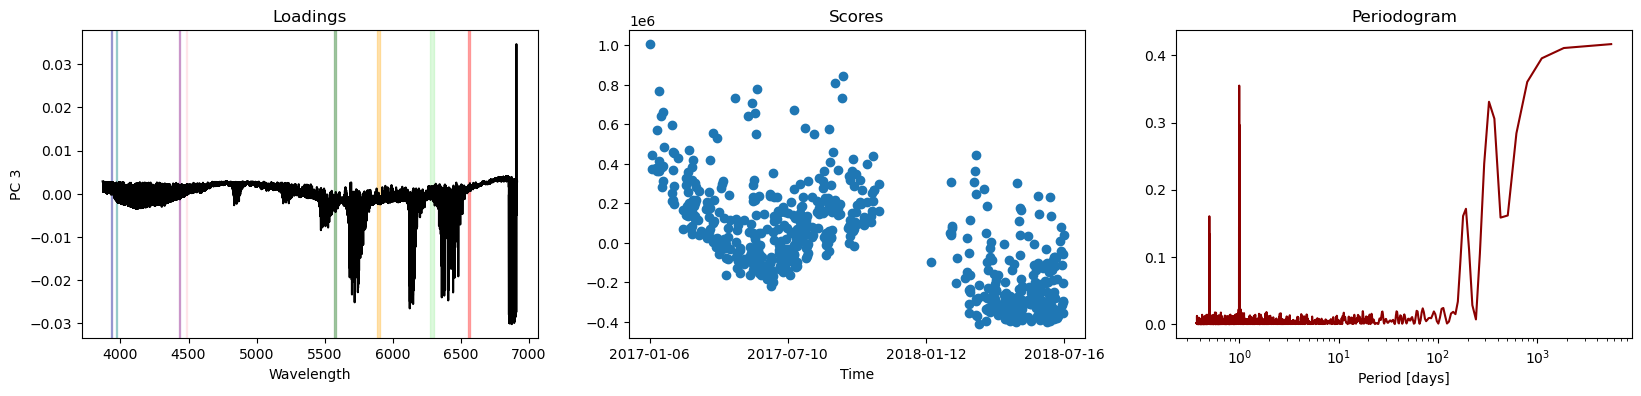

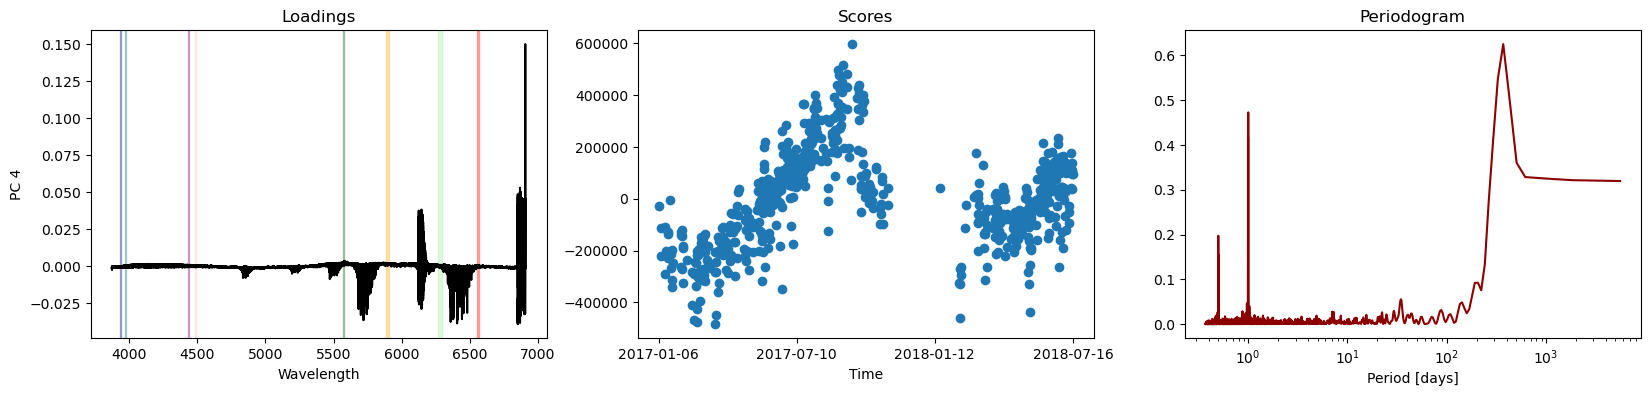

In [32]:
# plot
for i in range(n_components // 10):
    fig, axs = plt.subplots(1, 3, figsize=(20, 4))
    
    # Loadings
    axs[0].plot(wl, pca_flux.components_[i], color='k')
    for j in bands:
        axs[0].axvspan(xmin=j['start']*10, xmax=j['end']*10, color=j['color'], label=j['name'], alpha=.3)
    axs[0].set_title('Loadings', size=12)
    axs[0].set_xlabel('Wavelength')
    axs[0].set_ylabel(f'PC {i + 1}')
    
    # Scores
    axs[1].scatter(times, pcs[:, i])
    axs[1].set_title('Scores', size=12)
    axs[1].set_xlabel('Time')
    axs[1].set_xticks(np.linspace(times[0], times[-1], 4))

    # periodogram
    axs[2].plot(1 / periodograms[i][0], periodograms[i][1], color='darkred')
    axs[2].set_xscale('log')
    axs[2].set_title('Periodogram', size=12)
    axs[2].set_xlabel('Period [days]')
    
    plt.show()